# Employee Attrition prediction

## Dataset: IBM HR Analytics Attrition & Performance from Kaggle
### Goal: Predict whether an employee will leave the company
### Dataset URL: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

## 1. Import Libraries and Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f'Dataset Shape: {df.shape}')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
df.sample(10)

Dataset Shape: (1470, 35)
Rows: 1470, Columns: 35


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
926,43,No,Travel_Rarely,531,Sales,4,4,Marketing,1,1293,...,4,80,0,23,3,4,21,7,15,17
1033,31,Yes,Travel_Frequently,1445,Research & Development,1,5,Life Sciences,1,1459,...,1,80,0,10,2,3,10,8,4,7
192,35,Yes,Travel_Rarely,556,Research & Development,23,2,Life Sciences,1,261,...,1,80,0,8,1,3,1,0,0,1
1252,34,No,Travel_Rarely,181,Research & Development,2,4,Medical,1,1755,...,1,80,3,6,3,3,5,0,1,2
87,51,No,Travel_Rarely,432,Research & Development,9,4,Life Sciences,1,116,...,2,80,2,10,4,3,4,2,0,3
956,56,No,Travel_Rarely,206,Human Resources,8,4,Life Sciences,1,1338,...,1,80,0,36,4,3,7,3,7,7
186,40,No,Travel_Rarely,989,Research & Development,4,1,Medical,1,253,...,2,80,1,21,2,3,20,8,9,9
1463,31,No,Non-Travel,325,Research & Development,5,3,Medical,1,2057,...,2,80,0,10,2,3,9,4,1,7
1159,39,No,Travel_Frequently,711,Research & Development,4,3,Medical,1,1633,...,4,80,0,10,2,1,9,2,3,8
148,41,No,Travel_Rarely,933,Research & Development,9,4,Life Sciences,1,200,...,4,80,1,7,2,3,5,0,1,4


## Data cleaning

In [3]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [4]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [5]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [6]:
print('\n=== Duplicate Rows ===')
print(f'Duplicates: {df.duplicated().sum()}')


=== Duplicate Rows ===
Duplicates: 0


In [7]:
# Identify columns with single unique value — useless for modeling
single_val_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f'Constant columns (will be dropped): {single_val_cols}')

Constant columns (will be dropped): ['EmployeeCount', 'Over18', 'StandardHours']


In [8]:
# Check target distribution
print('Target Variable Distribution')
print(df['Attrition'].value_counts())
print(f'Attrition Rate: {df["Attrition"].value_counts(normalize=True)["Yes"]*100:.1f}%')

Target Variable Distribution
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition Rate: 16.1%


In [9]:
df_clean=df.copy()
# Drop columns with only 1 unique value (no predictive power)
# 'EmployeeCount', 'StandardHours', 'Over18' are constants in IBM dataset
cols_to_drop = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df_clean.drop(columns=cols_to_drop, inplace=True)
print(f'Dropped constant/ID columns: {cols_to_drop}')

Dropped constant/ID columns: ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']


In [10]:
# Encode target: Yes -> 1, No -> 0
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})
print(f'Target encoded. Shape after cleaning: {df_clean.shape}')

Target encoded. Shape after cleaning: (1470, 31)


## EDA

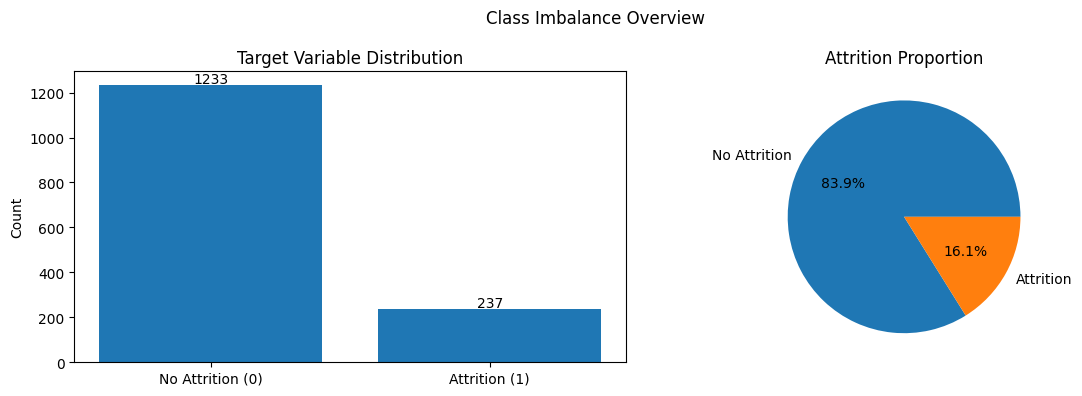

In [11]:
# Target Class Distribution
# INSIGHT: Dataset is imbalanced (~16% attrition). We'll need SMOTE
# to prevent the model from being biased toward predicting 'No attrition'.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df_clean['Attrition'].value_counts()
axes[0].bar(['No Attrition (0)', 'Attrition (1)'], counts.values)
axes[0].set_title('Target Variable Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center')

axes[1].pie(counts.values, labels=['No Attrition', 'Attrition'], autopct='%1.1f%%')
axes[1].set_title('Attrition Proportion')

plt.suptitle('Class Imbalance Overview')
plt.tight_layout()
plt.show()

C:\Users\meena\AppData\Local\Temp\ipykernel_28864\3101938292.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(ct.index, rotation=30, ha='right')
C:\Users\meena\AppData\Local\Temp\ipykernel_28864\3101938292.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(ct.index, rotation=30, ha='right')
C:\Users\meena\AppData\Local\Temp\ipykernel_28864\3101938292.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(ct.index, rotation=30, ha='right')
C:\Users\meena\AppData\Local\Temp\ipykernel_28864\3101938292.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels

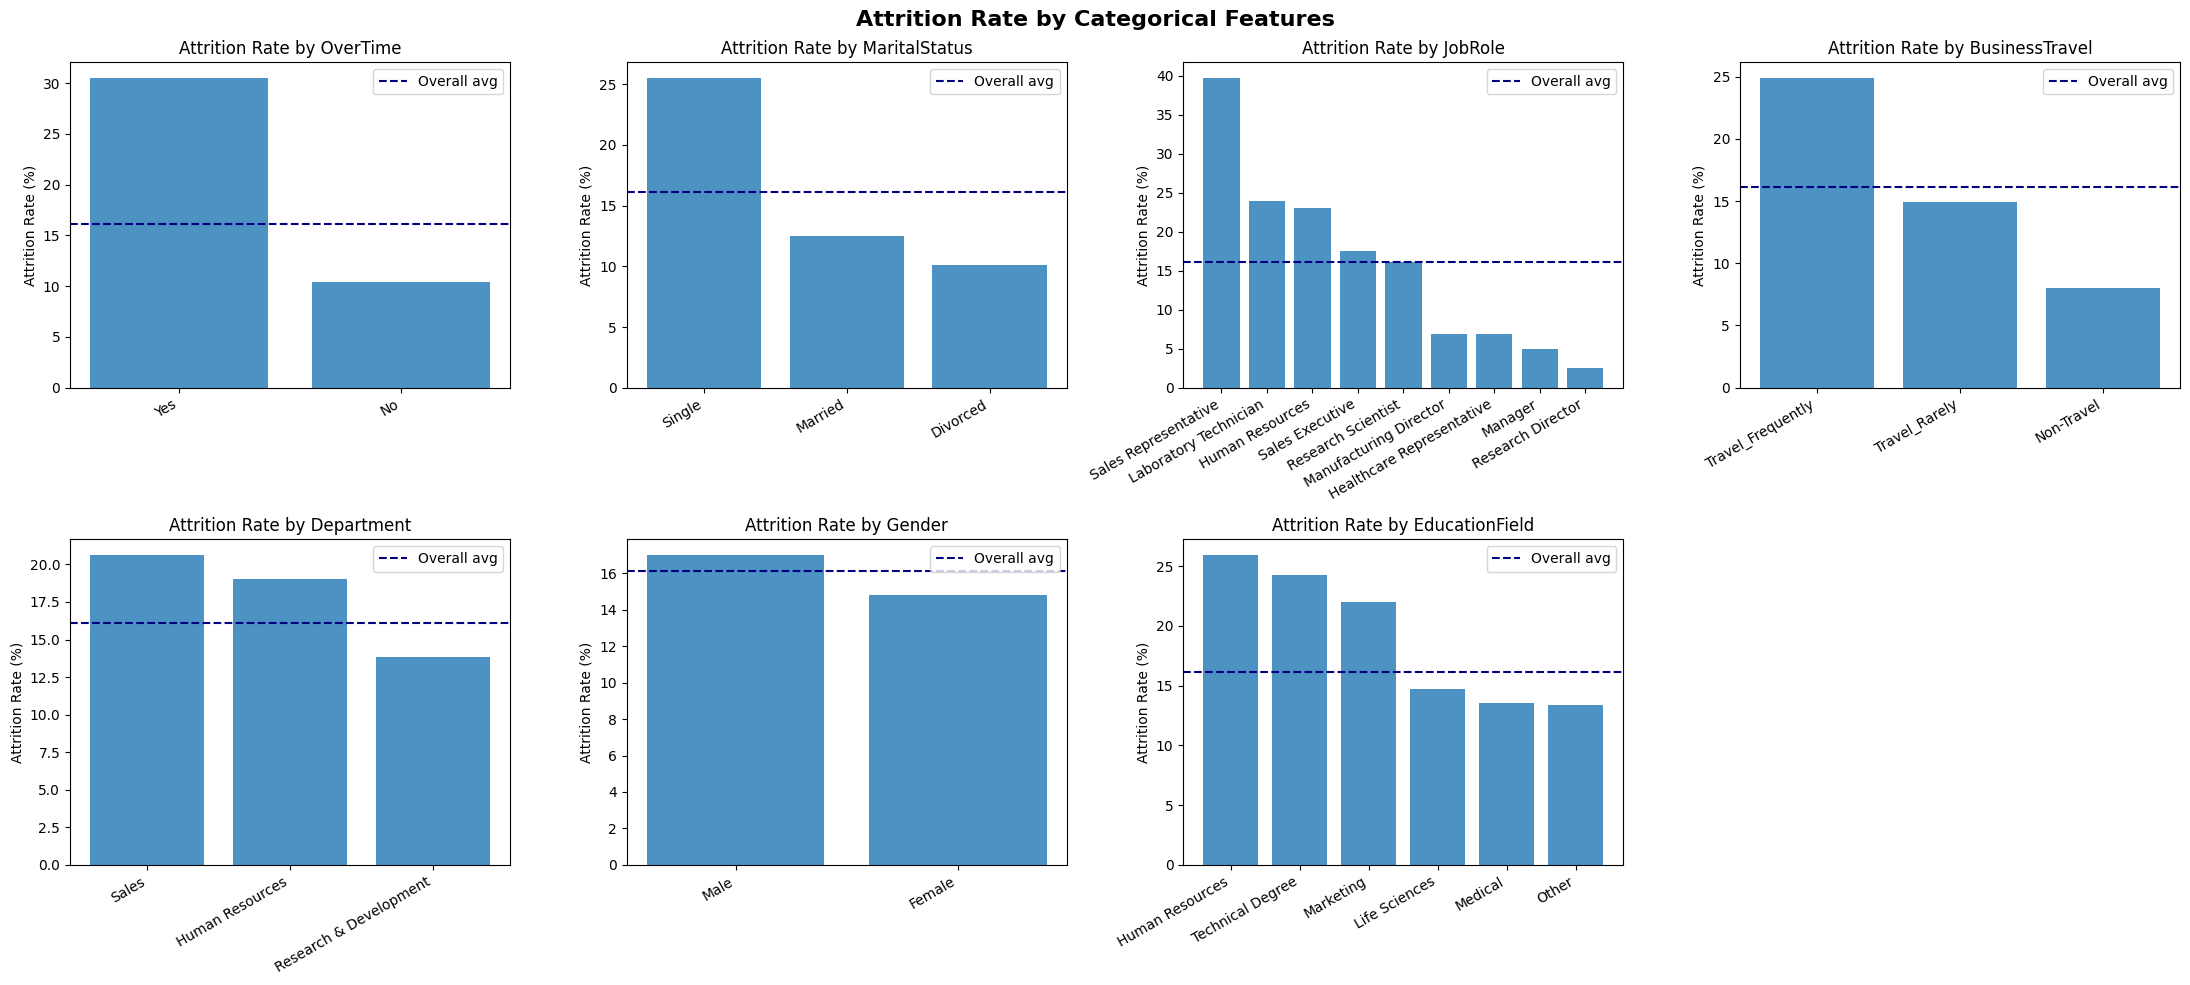

In [12]:
# Attrition by Key Categorical Features 

cat_features = ['OverTime', 'MaritalStatus', 'JobRole', 'BusinessTravel', 'Department', 'Gender', 'EducationField']
cat_features = [c for c in cat_features if c in df_clean.columns]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for idx, col in enumerate(cat_features):
    ct = df_clean.groupby(col)['Attrition'].mean().sort_values(ascending=False) * 100
    axes[idx].bar(ct.index, ct.values, alpha=0.8)
    axes[idx].set_title(f'Attrition Rate by {col}')
    axes[idx].set_ylabel('Attrition Rate (%)')
    axes[idx].set_xticklabels(ct.index, rotation=30, ha='right')
    axes[idx].axhline(y=df_clean['Attrition'].mean()*100, color='navy', linestyle='--', label='Overall avg')
    axes[idx].legend()

for i in range(len(cat_features), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Attrition Rate by Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# INSIGHT: Overtime employees show dramatically higher attrition (~30% vs ~10%).
# Single employees leave more than married/divorced ones — possibly less anchored.
# Sales Representatives have the highest attrition by job role.
# Travel-heavy roles correlate with higher turnover.

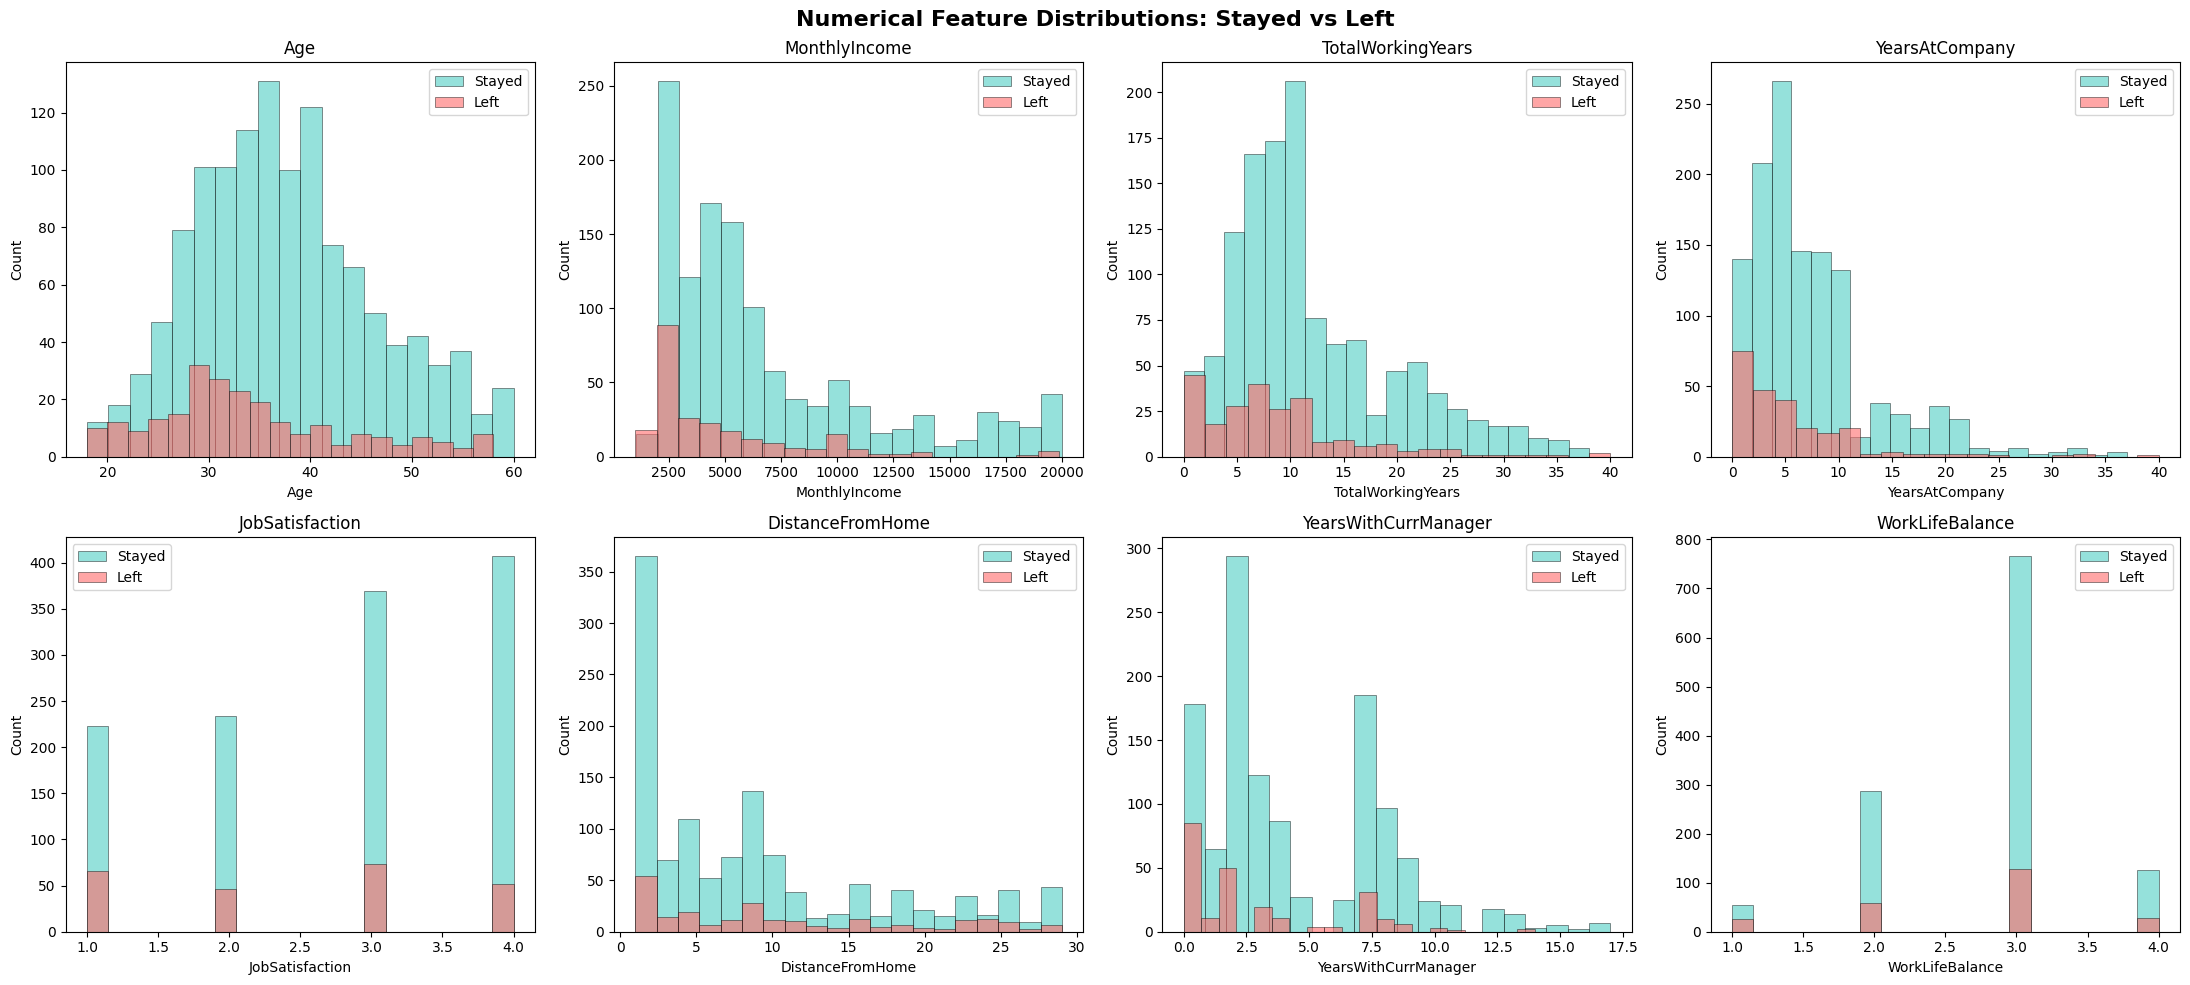

In [13]:
# Numerical Feature Distributions by Attrition

num_features = ['Age', 'MonthlyIncome', 'TotalWorkingYears',
                'YearsAtCompany', 'JobSatisfaction', 'DistanceFromHome',
                'YearsWithCurrManager', 'WorkLifeBalance']
num_features = [c for c in num_features if c in df_clean.columns]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for idx, col in enumerate(num_features):
    for val, color, label in [(0, '#4ECDC4', 'Stayed'), (1, '#FF6B6B', 'Left')]:
        axes[idx].hist(df_clean[df_clean['Attrition'] == val][col],
                       bins=20, alpha=0.6, color=color, label=label, edgecolor='black', linewidth=0.5)
    axes[idx].set_title(col)
    axes[idx].legend()
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')

plt.suptitle('Numerical Feature Distributions: Stayed vs Left', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# INSIGHT:
# - Younger employees (25-35) leave more; attrition drops sharply after 40.
# - Lower monthly income strongly predicts leaving — compensation matters.
# - Employees with low total working years are at higher risk.
# - Short tenure (YearsAtCompany <= 2) is a major red flag.
# - Low job satisfaction and environment satisfaction drive exits.

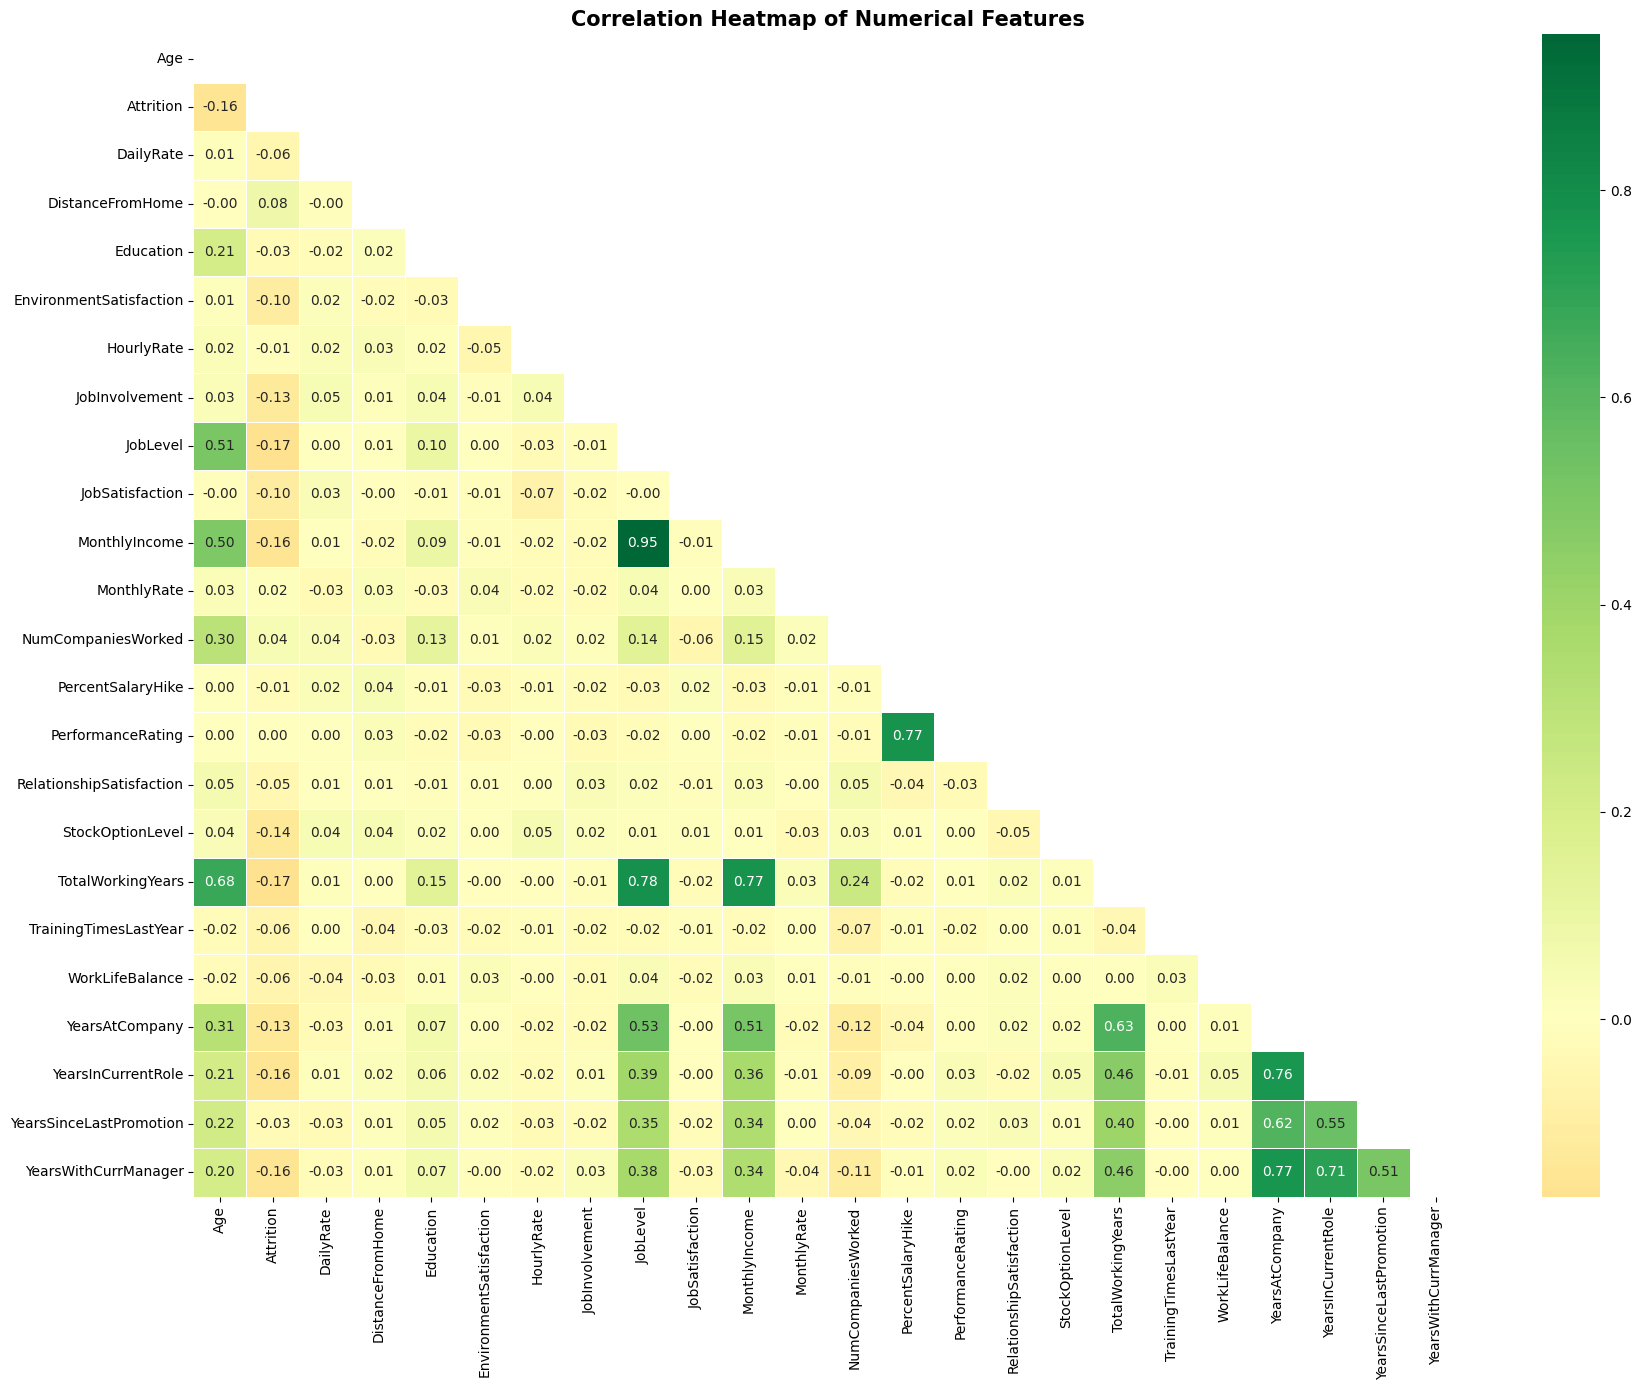

In [14]:
# Correlation Heatmap (Numerical Features)

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(18, 14))
corr_matrix = df_clean[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# INSIGHT:
# - Age, TotalWorkingYears, YearsAtCompany, MonthlyIncome are highly correlated
#   with each other (multicollinearity) — tree-based models handle this well.
# - Attrition negatively correlates with: Age, Income, TotalWorkingYears, YearsAtCompany.

C:\Users\meena\AppData\Local\Temp\ipykernel_28864\2298924850.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y=col, data=plot_df, ax=axes[idx],
C:\Users\meena\AppData\Local\Temp\ipykernel_28864\2298924850.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y=col, data=plot_df, ax=axes[idx],
C:\Users\meena\AppData\Local\Temp\ipykernel_28864\2298924850.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y=col, data=plot_df, ax=axes[idx],
C:\Users\meena\AppData\Local\Temp\ipykernel_28864\22989

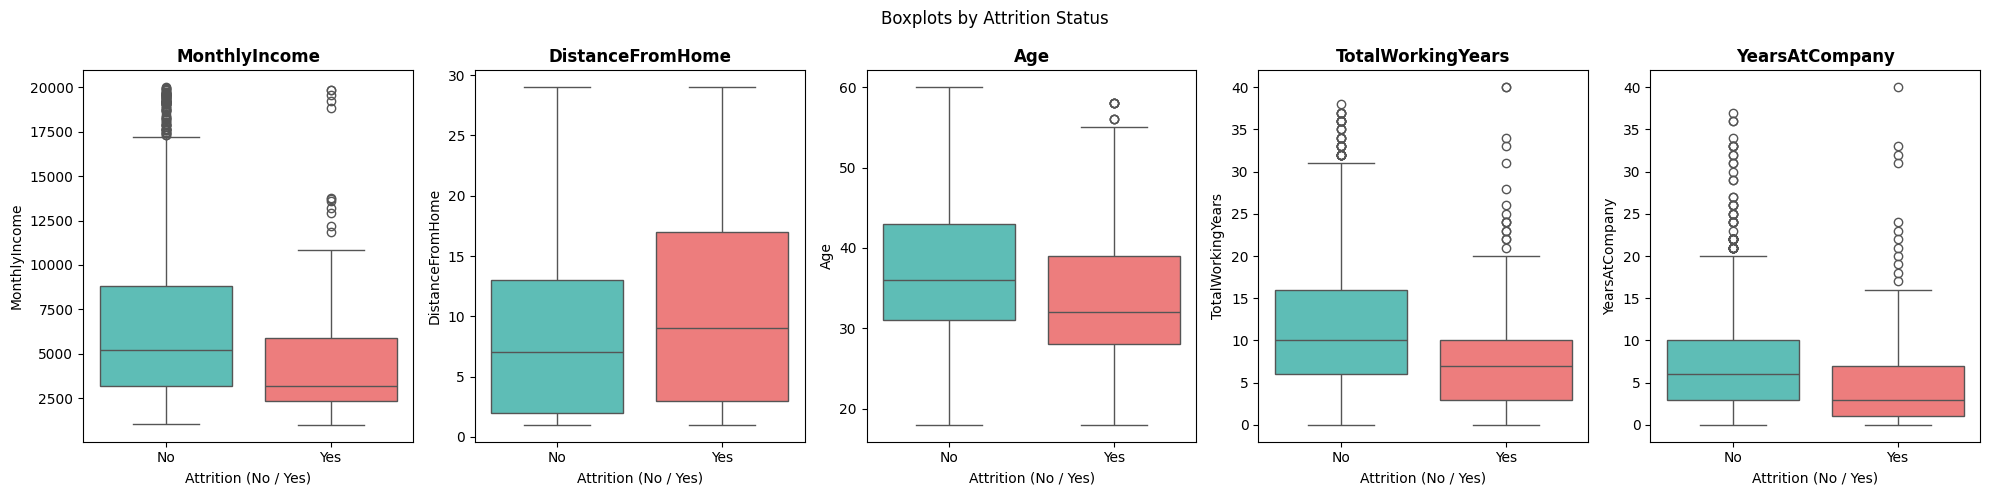

In [15]:
# Boxplots — Spotting Outliers

box_features = ['MonthlyIncome', 'DistanceFromHome', 'Age',
                'TotalWorkingYears', 'YearsAtCompany']
box_features = [c for c in box_features if c in df_clean.columns]

fig, axes = plt.subplots(1, len(box_features), figsize=(20, 5))

for idx, col in enumerate(box_features):
    plot_df = df_clean.copy()
    plot_df['Attrition'] = plot_df['Attrition'].map({0: 'No', 1: 'Yes'})
    sns.boxplot(x='Attrition', y=col, data=plot_df, ax=axes[idx],
                palette={'No': '#4ECDC4', 'Yes': '#FF6B6B'},
                order=['No', 'Yes'])
    axes[idx].set_title(col, fontweight='bold')
    axes[idx].set_xlabel('Attrition (No / Yes)')

plt.suptitle('Boxplots by Attrition Status')
plt.tight_layout()
plt.show()

# INSIGHT:
# - There are a large number of outliers
# - These are real-world values, not errors, so we retain them.

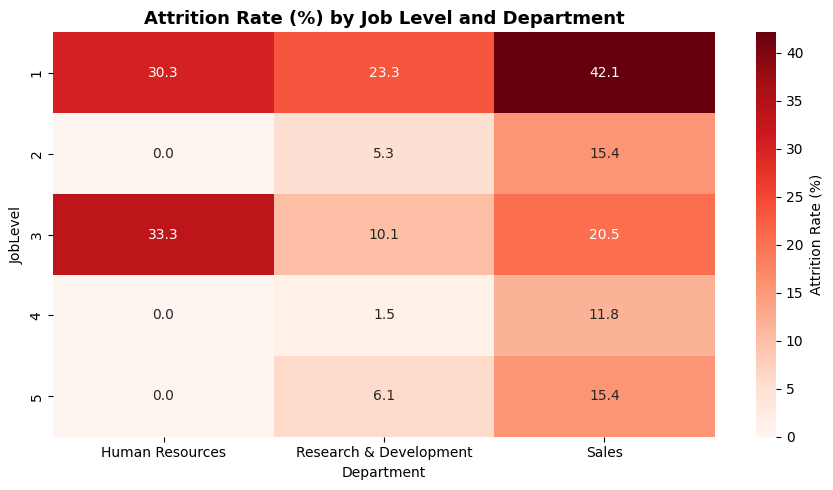

In [16]:
# Attrition Heatmap: JobLevel x Department

if 'JobLevel' in df_clean.columns and 'Department' in df_clean.columns:
    pivot = df_clean.pivot_table(values='Attrition', index='JobLevel',
                                  columns='Department', aggfunc='mean')
    plt.figure(figsize=(9, 5))
    sns.heatmap(pivot * 100, annot=True, fmt='.1f', cmap='Reds',
                cbar_kws={'label': 'Attrition Rate (%)'})
    plt.title('Attrition Rate (%) by Job Level and Department', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# INSIGHT: Junior (Level 1) employees in Sales have the highest attrition.
# R&D and HR at higher job levels show very low turnover.

## Feature Engineering and Preprocessing

In [17]:
# Create Composite Features
df_feat = df_clean.copy()

# Feature 1: TenureRatio
if 'YearsAtCompany' in df_feat.columns and 'TotalWorkingYears' in df_feat.columns:
    df_feat['TenureRatio'] = df_feat['YearsAtCompany'] / (df_feat['TotalWorkingYears'] + 1)

# Feature 2: IncomePerYearExp
if 'MonthlyIncome' in df_feat.columns and 'TotalWorkingYears' in df_feat.columns:
    df_feat['IncomePerYearExp'] = df_feat['MonthlyIncome'] / (df_feat['TotalWorkingYears'] + 1)

# Feature 3: SatisfactionScore
sat_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction']
if all(c in df_feat.columns for c in sat_cols):
    df_feat['SatisfactionScore'] = df_feat[sat_cols].mean(axis=1)

# Feature 4: PromotionStagnation
if 'YearsSinceLastPromotion' in df_feat.columns and 'YearsAtCompany' in df_feat.columns:
    df_feat['PromotionStagnation'] = df_feat['YearsSinceLastPromotion'] / (df_feat['YearsAtCompany'] + 1)

# Feature 5: ManagerStability
if 'YearsWithCurrManager' in df_feat.columns and 'YearsAtCompany' in df_feat.columns:
    df_feat['ManagerStability'] = df_feat['YearsWithCurrManager'] / (df_feat['YearsAtCompany'] + 1)

print('Engineered features created successfully.')
new_feats = ['TenureRatio', 'IncomePerYearExp', 'SatisfactionScore', 'PromotionStagnation', 'ManagerStability']
new_feats = [f for f in new_feats if f in df_feat.columns]
print(f'New features: {new_feats}')

Engineered features created successfully.
New features: ['TenureRatio', 'IncomePerYearExp', 'SatisfactionScore', 'PromotionStagnation', 'ManagerStability']


In [18]:
# Drop Redundant Source Columns
redundant_cols = [
    'YearsAtCompany', 'TotalWorkingYears', 'YearsWithCurrManager',
    'YearsSinceLastPromotion', 'JobSatisfaction', 'EnvironmentSatisfaction',
    'RelationshipSatisfaction', 'MonthlyRate', 'DailyRate', 'HourlyRate',
    'JobLevel', 'PercentSalaryHike',
]

redundant_cols = [c for c in redundant_cols if c in df_feat.columns]
df_feat.drop(columns=redundant_cols, inplace=True)

print(f'Dropped {len(redundant_cols)} redundant columns: {redundant_cols}')
print(f'Shape after dropping redundant cols: {df_feat.shape}')
print(f'\nRemaining columns ({df_feat.shape[1]}):')
print(df_feat.columns.tolist())

Dropped 12 redundant columns: ['YearsAtCompany', 'TotalWorkingYears', 'YearsWithCurrManager', 'YearsSinceLastPromotion', 'JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'MonthlyRate', 'DailyRate', 'HourlyRate', 'JobLevel', 'PercentSalaryHike']
Shape after dropping redundant cols: (1470, 24)

Remaining columns (24):
['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'Gender', 'JobInvolvement', 'JobRole', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'OverTime', 'PerformanceRating', 'StockOptionLevel', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsInCurrentRole', 'TenureRatio', 'IncomePerYearExp', 'SatisfactionScore', 'PromotionStagnation', 'ManagerStability']


In [19]:
# Identify Feature Types
X = df_feat.drop('Attrition', axis=1)
y = df_feat['Attrition']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols   = X.select_dtypes(include=[np.number]).columns.tolist()

print(f'Categorical features ({len(categorical_cols)}): {categorical_cols}')
print(f'Numerical features  ({len(numerical_cols)}): {numerical_cols}')
print(f'\nTotal features: {X.shape[1]}')

Categorical features (7): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Numerical features  (16): ['Age', 'DistanceFromHome', 'Education', 'JobInvolvement', 'MonthlyIncome', 'NumCompaniesWorked', 'PerformanceRating', 'StockOptionLevel', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsInCurrentRole', 'TenureRatio', 'IncomePerYearExp', 'SatisfactionScore', 'PromotionStagnation', 'ManagerStability']

Total features: 23


In [20]:
# Log Transform Skewed Numerical Features

# Identify Skewed Features 
num_after = df_feat.select_dtypes(include=[np.number]).drop('Attrition', axis=1).columns.tolist()
skew_after = df_feat[num_after].skew().abs().sort_values(ascending=False)

print('=== Skewness AFTER feature engineering (before log transform) ===')
print(skew_after.to_string())

ORDINAL_COLS = [
    'Education',
    'JobInvolvement',
    'PerformanceRating',
    'StockOptionLevel',
    'TrainingTimesLastYear',
    'WorkLifeBalance'
]

log_candidates = skew_after[(skew_after > 0.75)].index.tolist()
log_transform_cols = [c for c in log_candidates if c not in ORDINAL_COLS]

print(f'\nCols to log-transform: {log_transform_cols}')

=== Skewness AFTER feature engineering (before log transform) ===
PerformanceRating        1.921883
MonthlyIncome            1.369817
IncomePerYearExp         1.051231
NumCompaniesWorked       1.026471
StockOptionLevel         0.968980
DistanceFromHome         0.958118
YearsInCurrentRole       0.917363
PromotionStagnation      0.864135
TrainingTimesLastYear    0.553124
WorkLifeBalance          0.552480
JobInvolvement           0.498419
ManagerStability         0.496232
TenureRatio              0.478565
Age                      0.413286
Education                0.289681
SatisfactionScore        0.176197

Cols to log-transform: ['MonthlyIncome', 'IncomePerYearExp', 'NumCompaniesWorked', 'DistanceFromHome', 'YearsInCurrentRole', 'PromotionStagnation']


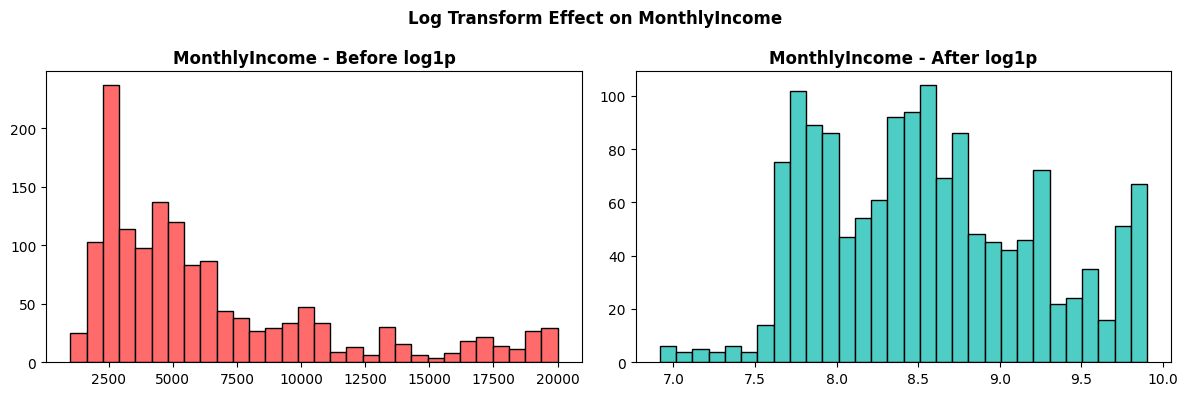


Skewness Before: 1.370
Skewness After : 0.286

Log-transformed 6 features.
Final model dataframe shape: (1470, 24)


In [21]:
# Apply log1p Transform
df_model = df_feat.copy()

for col in log_transform_cols:
    df_model[col] = np.log1p(df_model[col])

# Visualize most skewed transformed feature
if log_transform_cols:

    top_skewed = skew_after[log_transform_cols].idxmax()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(
        df_feat[top_skewed],
        bins=30,
        color='#FF6B6B',
        edgecolor='black'
    )
    axes[0].set_title(f'{top_skewed} - Before log1p', fontweight='bold')

    axes[1].hist(
        df_model[top_skewed],
        bins=30,
        color='#4ECDC4',
        edgecolor='black'
    )
    axes[1].set_title(f'{top_skewed} - After log1p', fontweight='bold')

    plt.suptitle(
        f'Log Transform Effect on {top_skewed}',
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()

    print(f'\nSkewness Before: {df_feat[top_skewed].skew():.3f}')
    print(f'Skewness After : {df_model[top_skewed].skew():.3f}')

print(f'\nLog-transformed {len(log_transform_cols)} features.')
print(f'Final model dataframe shape: {df_model.shape}')

## Train test split + SMOTEENN resampling

## SMOTEENN = SMOTE (synthetic minority oversampling) + ENN (Edited Nearest Neighbours undersampling). It oversamples the minority class with synthetic points, then removes noisy/borderline samples from both classes using ENN — giving a cleaner decision boundary.

In [22]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [23]:
# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import SelectFromModel
from statsmodels.stats.outliers_influence import variance_inflation_factor

from xgboost import XGBClassifier

# Imbalanced-learn
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE

X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols   = X.select_dtypes(include=[np.number]).columns.tolist()

print(f'Categorical features ({len(categorical_cols)}): {categorical_cols}')
print(f'Numerical features  ({len(numerical_cols)}): {numerical_cols}')
print(f'Total features: {X.shape[1]}')

Categorical features (7): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Numerical features  (16): ['Age', 'DistanceFromHome', 'Education', 'JobInvolvement', 'MonthlyIncome', 'NumCompaniesWorked', 'PerformanceRating', 'StockOptionLevel', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsInCurrentRole', 'TenureRatio', 'IncomePerYearExp', 'SatisfactionScore', 'PromotionStagnation', 'ManagerStability']
Total features: 23


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Train attrition rate: {y_train.mean()*100:.1f}%')
print(f'Test  attrition rate: {y_test.mean()*100:.1f}%')

Train size: 1176 | Test size: 294
Train attrition rate: 16.2%
Test  attrition rate: 16.0%


In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numerical_cols),
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            drop='first',
            sparse_output=False
        ), categorical_cols)
    ]
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f'Processed train shape: {X_train_proc.shape}')
print(f'Processed test shape:  {X_test_proc.shape}')

Processed train shape: (1176, 37)
Processed test shape:  (294, 37)


In [26]:
from imblearn.combine import SMOTEENN

smoteenn = SMOTEENN(random_state=42)

X_train_balanced, y_train_balanced = smoteenn.fit_resample(
    X_train_proc,
    y_train
)

print("Before SMOTEENN:")
print(y_train.value_counts())

print("\nAfter SMOTEENN:")
print(y_train_balanced.value_counts())

Before SMOTEENN:
Attrition
0    986
1    190
Name: count, dtype: int64

After SMOTEENN:
Attrition
1    969
0    480
Name: count, dtype: int64


## Baseline Model Comparison

In [27]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ),

    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        random_state=42
    ),

    'AdaBoost': AdaBoostClassifier(
        n_estimators=200,
        random_state=42
    ),

    'SVM': SVC(
        probability=True,
        random_state=42,
        class_weight='balanced'
    ),

    'KNN': KNeighborsClassifier(
        n_neighbors=5
    ),

    'Naive Bayes': GaussianNB(),

    'XGBoost': XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
    ),
}

print(f"{len(models)} models registered.")

9 models registered.


In [28]:
results = []

for name, model in models.items():

    model.fit(
        X_train_balanced,
        y_train_balanced
    )

    y_pred = model.predict(X_test_proc)

    y_proba = model.predict_proba(
        X_test_proc
    )[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

    print(
        f"✅ {name:<25}"
        f" F1={f1_score(y_test,y_pred):.3f}"
        f" | ROC-AUC={roc_auc_score(y_test,y_proba):.3f}"
    )

results_df = (
    pd.DataFrame(results)
      .sort_values('F1 Score', ascending=False)
      .reset_index(drop=True)
)

print("\n=== MODEL COMPARISON ===")
display(results_df)

✅ Logistic Regression       F1=0.466 | ROC-AUC=0.786
✅ Decision Tree             F1=0.321 | ROC-AUC=0.596
✅ Random Forest             F1=0.420 | ROC-AUC=0.774
✅ Gradient Boosting         F1=0.424 | ROC-AUC=0.759
✅ AdaBoost                  F1=0.459 | ROC-AUC=0.771
✅ SVM                       F1=0.451 | ROC-AUC=0.715
✅ KNN                       F1=0.316 | ROC-AUC=0.648
✅ Naive Bayes               F1=0.327 | ROC-AUC=0.650
✅ XGBoost                   F1=0.444 | ROC-AUC=0.769

=== MODEL COMPARISON ===


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.734694,0.343434,0.723404,0.465753,0.786028
1,AdaBoost,0.775510,0.373333,0.595745,0.459016,0.770867
2,SVM,0.751701,0.348837,0.638298,0.451128,0.715479
3,XGBoost,0.778912,0.371429,0.553191,0.444444,0.768886
4,Gradient Boosting,0.768707,0.352113,0.531915,0.423729,0.758980
5,Random Forest,0.765306,0.347222,0.531915,0.420168,0.774055
6,Naive Bayes,0.523810,0.211180,0.723404,0.326923,0.649539
7,Decision Tree,0.697279,0.250000,0.446809,0.320611,0.595874
8,KNN,0.469388,0.198895,0.765957,0.315789,0.647902


In [29]:
top3_models = results_df.head(3)

print("Top 3 Models:")
display(top3_models[['Model','F1 Score','ROC-AUC']])

Top 3 Models:


,Model,F1 Score,ROC-AUC
0,Logistic Regression,0.465753,0.786028
1,AdaBoost,0.459016,0.770867
2,SVM,0.451128,0.715479


## Hyperparameter tuning

In [30]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# AdaBoost Tuning
print('Tuning AdaBoost...')

ada_params = {
    'n_estimators': [50, 100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]
}

ada_grid = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    ada_params,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

ada_grid.fit(
    X_train_balanced,
    y_train_balanced
)

print(f'Best Ada Params:  {ada_grid.best_params_}')
print(f'Best Ada ROC-AUC: {ada_grid.best_score_:.4f}')

Tuning AdaBoost...
Best Ada Params:  {'learning_rate': 1.0, 'n_estimators': 300}
Best Ada ROC-AUC: 0.9754


In [31]:
# SVM Tuning
print('Tuning SVM...')

svm_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(
    SVC(
        probability=True,
        random_state=42,
        class_weight='balanced'
    ),
    svm_params,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

svm_grid.fit(
    X_train_balanced,
    y_train_balanced
)

print(f'Best SVM Params:  {svm_grid.best_params_}')
print(f'Best SVM ROC-AUC: {svm_grid.best_score_:.4f}')

Tuning SVM...
Best SVM Params:  {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best SVM ROC-AUC: 0.9983


In [32]:
# Logistic Regression Tuning 
print('Tuning Logistic Regression...')
lr_params = {
    'C':            [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty':      ['l1', 'l2'],
    'solver':       ['liblinear'],
    'class_weight': ['balanced', None]
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_params, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0
)
lr_grid.fit(X_train_balanced, y_train_balanced)

print(f'Best LR Params:  {lr_grid.best_params_}')
print(f'Best LR ROC-AUC: {lr_grid.best_score_:.4f}')

Tuning Logistic Regression...
Best LR Params:  {'C': 100, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Best LR ROC-AUC: 0.9169


In [33]:
# XGBoost Tuning (RandomizedSearchCV)

from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

print('Tuning XGBoost...')

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_random = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_distributions=xgb_params,
    n_iter=50,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

xgb_random.fit(
    X_train_balanced,
    y_train_balanced
)

print(f'Best XGB Params:  {xgb_random.best_params_}')
print(f'Best XGB ROC-AUC: {xgb_random.best_score_:.4f}')

Tuning XGBoost...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best XGB Params:  {'subsample': 0.8, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best XGB ROC-AUC: 0.9861


In [34]:
# Compare Tuned Models 
tuned_models = {
    'XGBoost (Tuned)':       xgb_random.best_estimator_,
    'Adaboost (Tuned)':   ada_grid.best_estimator_,
    'SVM (Tuned)':   svm_grid.best_estimator_,
    'Logistic Regression (Tuned)': lr_grid.best_estimator_
}

tuned_results = []
for name, model in tuned_models.items():
    y_pred  = model.predict(X_test_proc)
    y_proba = model.predict_proba(X_test_proc)[:, 1]
    tuned_results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred),
        'F1 Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_proba)
    })

tuned_df = pd.DataFrame(tuned_results).sort_values('F1 Score', ascending=False).reset_index(drop=True)
print('=== Tuned Models Comparison ===')
tuned_df

=== Tuned Models Comparison ===


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost (Tuned),0.809524,0.428571,0.574468,0.490909,0.766905
1,Adaboost (Tuned),0.782313,0.383562,0.595745,0.466667,0.772849
2,Logistic Regression (Tuned),0.727891,0.339806,0.744681,0.466667,0.775261
3,SVM (Tuned),0.731293,0.309524,0.553191,0.396947,0.700146


In [35]:
# Testing Logistic Regression without SMOTEENN 

lr_grid.fit(X_train_proc, y_train)
lr_y_pred=lr_grid.predict(X_test_proc)
y_proba = lr_grid.predict_proba(
        X_test_proc
    )[:, 1]

print('Accuracy:', accuracy_score(y_test, lr_y_pred))
print('Precision:', precision_score(
            y_test,
            lr_y_pred))
print('Recall:', recall_score(y_test, lr_y_pred))
print('F1 Score:', f1_score(y_test, lr_y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_proba))

Accuracy: 0.8605442176870748
Precision: 0.6
Recall: 0.3829787234042553
F1 Score: 0.4675324675324675
ROC-AUC: 0.8005857524334569


## Final Model Selection
### Initial experiments suggested that tuned XGBoost was the strongest model when trained on SMOTEENN-balanced data. To verify whether resampling was genuinely beneficial, an additional experiment was conducted using the original imbalanced dataset.
### Surprisingly, Logistic Regression achieved a higher ROC-AUC and competitive F1 Score without any resampling, indicating that the underlying feature space was already informative and that SMOTEENN was not necessary for this model.
### Therefore, Logistic Regression was selected as the final candidate model for deployment and further optimization.

## Threshold Optimisation

In [36]:
y_proba = lr_grid.predict_proba(X_test_proc)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)

best_f1 = 0
best_threshold = 0.5

for threshold in thresholds:

    preds = (y_proba >= threshold).astype(int)

    f1 = f1_score(y_test, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)

Best Threshold: 0.24999999999999992
Best F1: 0.5769230769230769


In [37]:
final_preds = (y_proba >= best_threshold).astype(int)

print("Accuracy :", accuracy_score(y_test, final_preds))
print("Precision:", precision_score(y_test, final_preds))
print("Recall   :", recall_score(y_test, final_preds))
print("F1 Score :", f1_score(y_test, final_preds))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba))

print("\nClassification Report")
print(classification_report(y_test, final_preds))

Accuracy : 0.8503401360544217
Precision: 0.5263157894736842
Recall   : 0.6382978723404256
F1 Score : 0.5769230769230769
ROC-AUC  : 0.8005857524334569

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       247
           1       0.53      0.64      0.58        47

    accuracy                           0.85       294
   macro avg       0.73      0.76      0.74       294
weighted avg       0.86      0.85      0.86       294



## Final Model Evaluation

In [38]:
final_results = pd.DataFrame([{
    'Model': 'Logistic Regression',
    'Threshold': round(best_threshold, 2),
    'Accuracy': accuracy_score(y_test, final_preds),
    'Precision': precision_score(y_test, final_preds),
    'Recall': recall_score(y_test, final_preds),
    'F1 Score': f1_score(y_test, final_preds),
    'ROC-AUC': roc_auc_score(y_test, y_proba)
}])

final_results

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.25,0.85034,0.526316,0.638298,0.576923,0.800586


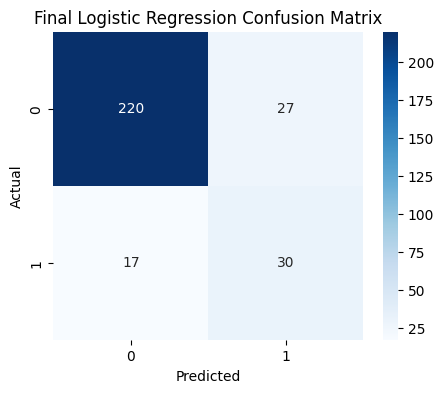

In [39]:
cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Logistic Regression Confusion Matrix')

plt.show()

In [40]:
feature_names = preprocessor.get_feature_names_out()

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_grid.best_estimator_.coef_[0]
})

coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()

coef_df = coef_df.sort_values(
    'AbsCoefficient',
    ascending=False
)

coef_df

,Feature,Coefficient,AbsCoefficient
16,cat__BusinessTravel_Travel_Frequently,1.918855,1.918855
36,cat__OverTime_Yes,1.891615,1.891615
33,cat__JobRole_Sales Representative,1.564347,1.564347
23,cat__EducationField_Other,-1.543406,1.543406
27,cat__JobRole_Laboratory Technician,1.189316,1.189316
22,cat__EducationField_Medical,-1.181482,1.181482
32,cat__JobRole_Sales Executive,1.177953,1.177953
13,num__SatisfactionScore,-1.146388,1.146388
4,num__MonthlyIncome,-1.050460,1.050460
20,cat__EducationField_Life Sciences,-1.006379,1.006379


## Save the model

In [41]:
import joblib

joblib.dump(
    lr_grid.best_estimator_,
    'attrition_model.pkl'
)

joblib.dump(
    preprocessor,
    'preprocessor.pkl'
)

joblib.dump(
    best_threshold,
    'threshold.pkl'
)

print("Artifacts saved successfully.")

Artifacts saved successfully.


In [42]:
model = joblib.load('attrition_model.pkl')
preprocessor = joblib.load('preprocessor.pkl')
threshold = joblib.load('threshold.pkl')

print(type(model))
print(type(preprocessor))
print(threshold)

<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.compose._column_transformer.ColumnTransformer'>
0.24999999999999992


In [44]:
X_sample = X_test.iloc[:20]

X_sample_proc = preprocessor.transform(X_sample)

print("Predictions:")
print(model.predict(X_sample_proc))

print("\nUnique Predictions:")
print(np.unique(model.predict(X_sample_proc), return_counts=True))

print("\nProbabilities:")
print(model.predict_proba(X_sample_proc)[:10])

Predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]

Unique Predictions:
(array([0, 1]), array([19,  1]))

Probabilities:
[[0.85759964 0.14240036]
 [0.99850904 0.00149096]
 [0.91166815 0.08833185]
 [0.99647317 0.00352683]
 [0.62915051 0.37084949]
 [0.79222499 0.20777501]
 [0.99405244 0.00594756]
 [0.97237893 0.02762107]
 [0.9959418  0.0040582 ]
 [0.75678076 0.24321924]]


In [43]:
print(df_feat.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'Gender', 'JobInvolvement', 'JobRole', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'OverTime', 'PerformanceRating', 'StockOptionLevel', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsInCurrentRole', 'TenureRatio', 'IncomePerYearExp', 'SatisfactionScore', 'PromotionStagnation', 'ManagerStability']
